# metrics.csv 訓練曲線

讀 `<exp_dir>/train/metrics.csv`,依欄位命名慣例分組(同一種指標、不同層疊在同一張子圖比較)畫出來。

渲染邏輯本身在 `viz/epoch_series.py`(通用,不知道這裡的欄位代表什麼、也不知道哪些欄該疊在一起);
「哪些欄其實是同一種指標、只是不同層」是 `example/metrics_log.py` 特有的欄位命名知識,只在這份 notebook 裡,不進 `viz`。

In [5]:
%matplotlib inline
import os

import matplotlib.pyplot as plt

from example.paths import EXPERIMENTS_DIR
from example.utils import TRAIN_DIRNAME
from viz.epoch_series import EpochSeriesPlot, read_epoch_series_csv

## 參數

改這裡,不改函式庫。

In [ ]:
RUN_NAME = "conv_compressed_compressed_maxsteps_verify_20260914_122946"
EXP_DIR = EXPERIMENTS_DIR / RUN_NAME  # 絕對路徑,跟 kernel 的工作目錄無關
NCOLS = 4

## 欄位分組

跟 `example/metrics_log.py` 組欄名用的 `f"{name}_{suffix}"` 是同一套字尾——`_METRIC_GROUPS` 就是「哪些欄其實是同一種指標、只是不同層,或同一個資源的容量跟用量」的定義:`event_queue`/`layer_spikes`/`steps` 各自把 `max_*`/`obs_*` 兩欄疊進同一張子圖對照(容量是階梯狀、用量在下面波動)。`decoder_*` 分在一組,其餘(`train_loss`/`val_accuracy`)各自獨立一組。

In [7]:
_METRIC_GROUPS = {
    "firing_rate": ["firing_rate"],
    "grad_norm": ["grad_norm"],
    "dormant_frac": ["dormant_frac"],
    "event_queue": ["max_event_queue", "obs_event_queue"],
    "layer_spikes": ["max_layer_spikes", "obs_layer_spikes"],
    "steps": ["max_steps", "obs_steps"],
}


def group_metrics_columns(columns: list) -> dict:
    """把 metrics.csv 的欄名(不含 epoch)分組:同一個資源(不同層、或同一層的
    容量 vs 用量)分在一組、decoder_* 分在一組,其餘各自獨立一組。回傳的 dict
    保留欄位第一次出現的順序。"""
    groups: dict = {}
    for col in columns:
        if col.startswith("decoder_"):
            groups.setdefault("decoder", []).append(col)
            continue
        matched = next((g for g, suffixes in _METRIC_GROUPS.items()
                        if any(col.endswith("_" + s) for s in suffixes)), None)
        if matched:
            groups.setdefault(matched, []).append(col)
        else:
            groups[col] = [col]
    return groups

## 讀資料、畫圖

findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.


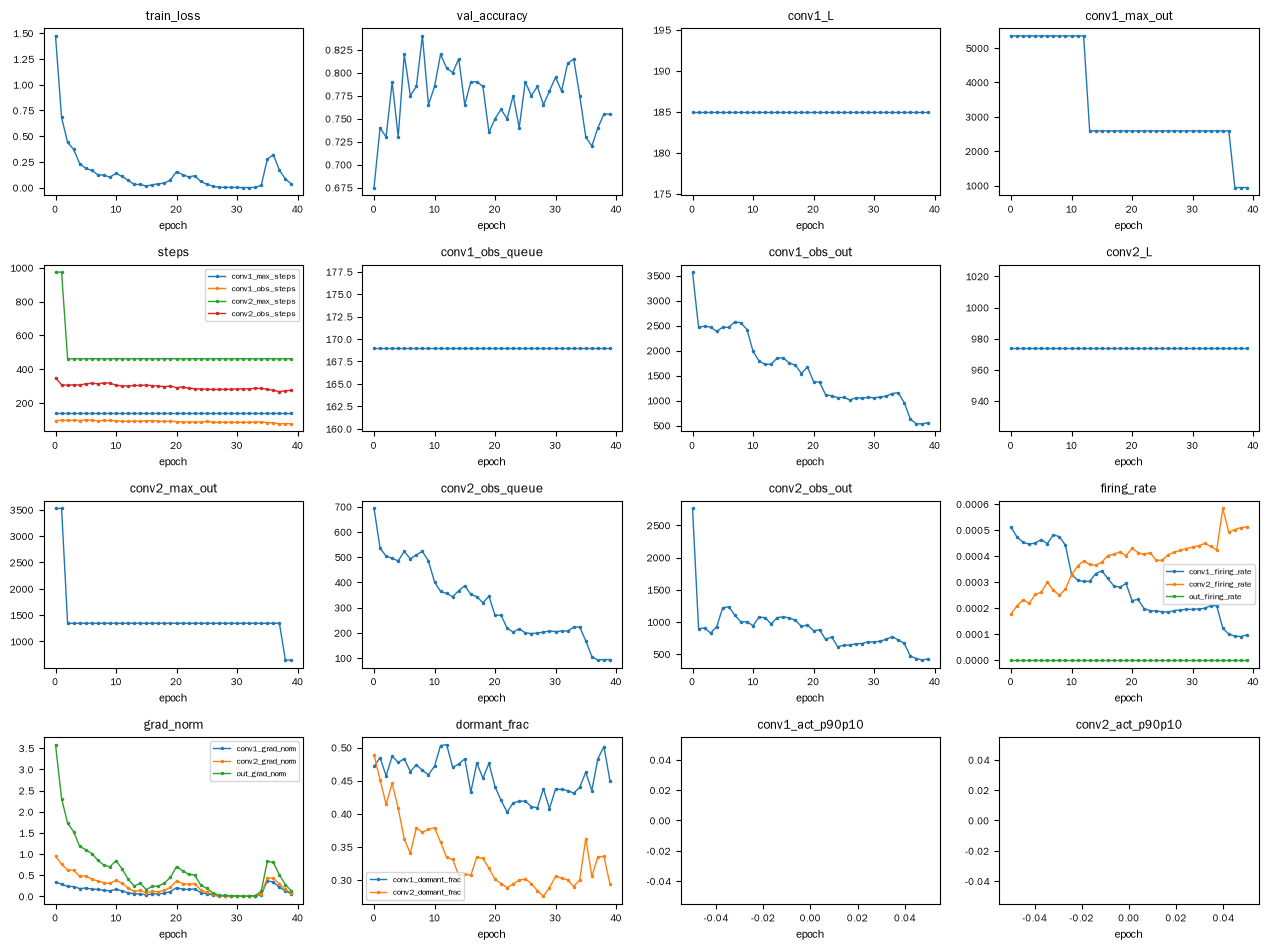

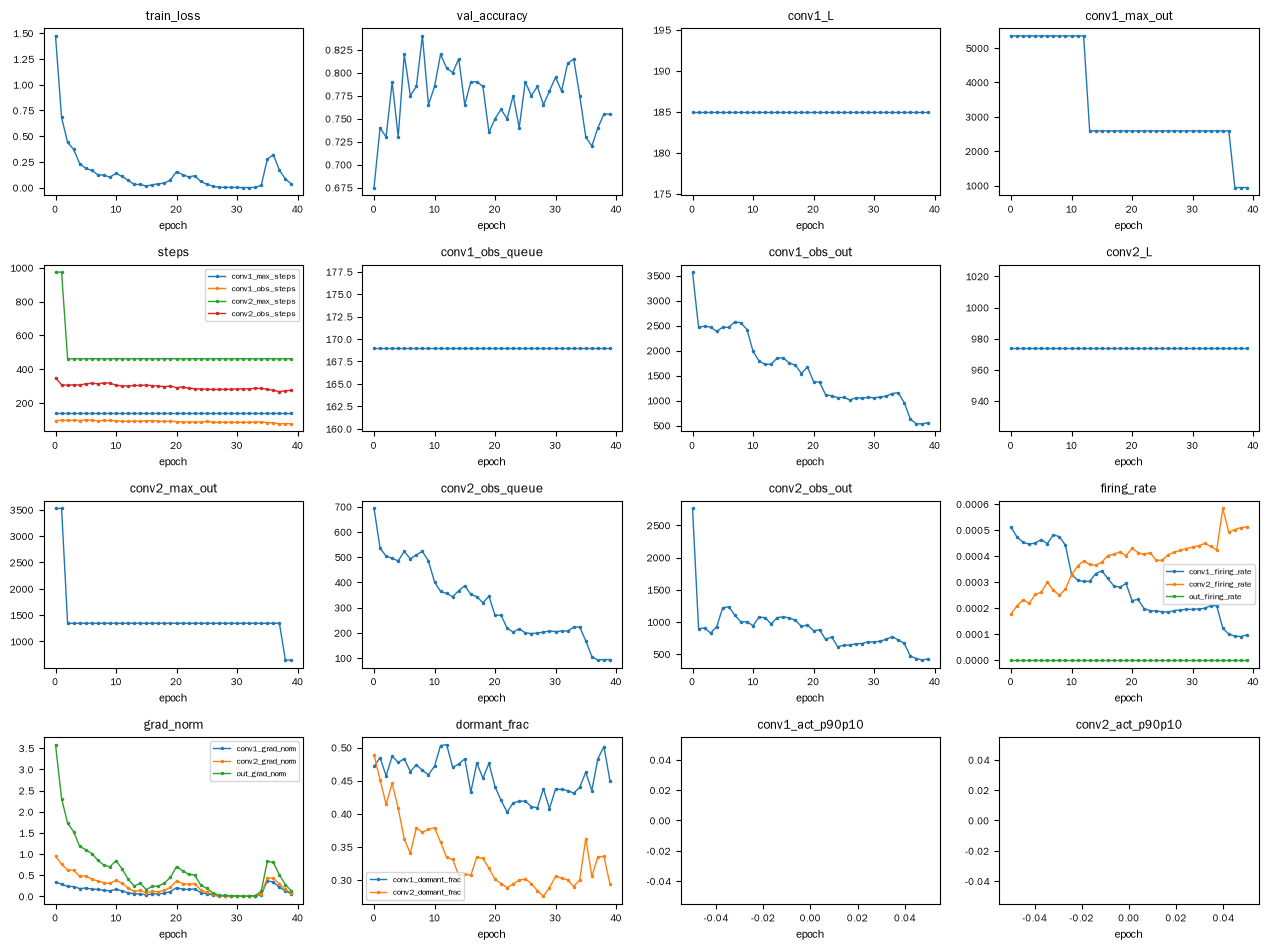

In [8]:
csv_path = os.path.join(EXP_DIR, TRAIN_DIRNAME, "metrics.csv")
rows = read_epoch_series_csv(csv_path)
groups = group_metrics_columns([k for k in rows[0].keys() if k != "epoch"])
fig = EpochSeriesPlot(groups=groups, ncols=NCOLS).render(rows)
fig

## 存檔(選用)

In [9]:
out_path = os.path.join(EXP_DIR, TRAIN_DIRNAME, "metrics.png")
fig.savefig(out_path, dpi=150)
print(f"寫入 {out_path}")

寫入 /home/salt/Projects/Spiking-Affine-Lazy-Training/experiments/conv_compressed_compressed_maxsteps_verify_20260913_120425/train/metrics.png
